# Phase 2 — Target construction & modelling-ready dataset

**Objectifs**
1. Appliquer **deux mappings NPS** (baseline + alternative) sur l'ensemble du dataset.
2. **Sensitivity analysis chiffrée** : à quel point le choix de mapping change la cible ?
3. Imputer proprement : `Total Charges` (Tenure × Monthly Charges) et `Internet Type` (NaN → "None").
4. Drop systématique des `LEAKY_FEATURES`, constantes et identifiants.
5. Sauvegarder `data/processed/dataset.parquet` + métadonnées JSON.
6. Valider les invariants (tests pytest dans `tests/test_phase2.py`).

**Sortie principale** : un dataset modélisable, ~7 043 × ~42 colonnes (40 features + 2 targets), indexé sur `Customer ID`.

## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_INTERIM, DATA_PROCESSED, FIGURES_DIR,
    NPS_CLASSES, NPS_MAPPINGS, LEAKY_FEATURES,
)
from src.data.load import load_raw_telco
from src.data.target import add_all_targets, summarise_mappings, TARGET_PREFIX
from src.data.build_dataset import (
    impute_total_charges, impute_internet_type,
    drop_leakers_and_constants, validate_dataset,
    build_dataset, save,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
NPS_PALETTE = {"Detractor": "#d62728", "Passive": "#ff7f0e", "Promoter": "#2ca02c"}
print("Setup OK")

Setup OK


## 1. Chargement & application des deux mappings

In [3]:
df_raw = load_raw_telco(verbose=False)
print(f"Shape raw: {df_raw.shape}")

df = add_all_targets(df_raw)
print(f"Shape after adding targets: {df.shape}")
print(f"\nNew target columns: {[c for c in df.columns if c.startswith(TARGET_PREFIX)]}")

  Multi-file layout detected (6 files)
    · Telco_customer_churn.xlsx:  7043 rows × 33 cols
    · Telco_customer_churn_demographics.xlsx:  7043 rows ×  9 cols
    · Telco_customer_churn_location.xlsx:  7043 rows ×  9 cols
    · Telco_customer_churn_population.xlsx:  1671 rows ×  3 cols
    · Telco_customer_churn_services.xlsx:  7043 rows × 30 cols
    · Telco_customer_churn_status.xlsx:  7043 rows × 11 cols

  Base file: Telco_customer_churn (7043 rows × 33 cols)
    + Telco_customer_churn_services: +13 new cols → 7043 × 46
    + Telco_customer_churn_status: +3 new cols → 7043 × 49
    + Telco_customer_churn_demographics: +4 new cols → 7043 × 53
    - Telco_customer_churn_location: no new columns, skipped
    + Telco_customer_churn_population: joined on Zip Code, +2 cols
Shape raw: (7043, 55)
Shape after adding targets: (7043, 57)

New target columns: ['NPS_baseline', 'NPS_alternative']


## 2. Sensitivity analysis — distribution par mapping

In [4]:
summary = summarise_mappings(df)
print("Class distribution under each mapping:\n")
print(summary)

Class distribution under each mapping:

           baseline_n  baseline_pct  alternative_n  alternative_pct
Detractor        4105          58.3           1440             20.4
Passive          1789          25.4           4454             63.2
Promoter         1149          16.3           1149             16.3


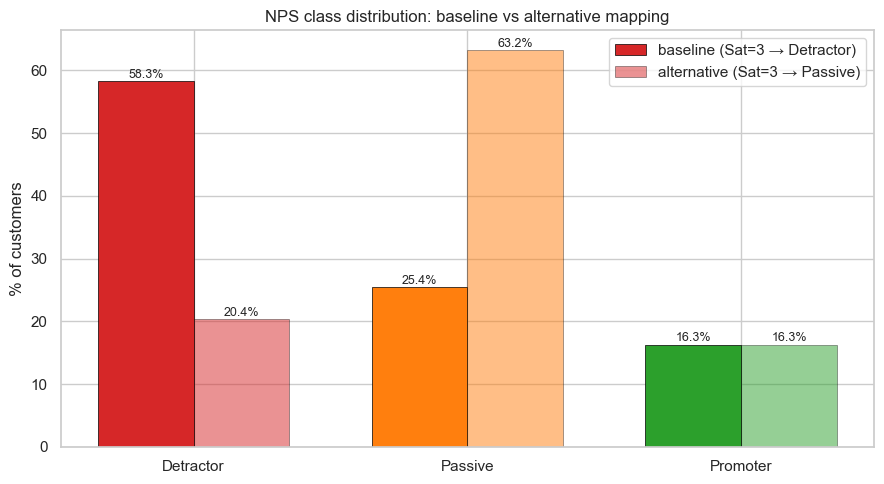

In [5]:
# Side-by-side bar chart
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(NPS_CLASSES))
width = 0.35

baseline_pct = summary["baseline_pct"].values
alternative_pct = summary["alternative_pct"].values

bars1 = ax.bar(x - width/2, baseline_pct, width, label="baseline (Sat=3 → Detractor)",
               color=[NPS_PALETTE[c] for c in NPS_CLASSES], edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, alternative_pct, width, label="alternative (Sat=3 → Passive)",
               color=[NPS_PALETTE[c] for c in NPS_CLASSES], alpha=0.5,
               edgecolor="black", linewidth=0.5)

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f"{h:.1f}%", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(NPS_CLASSES)
ax.set_ylabel("% of customers")
ax.set_title("NPS class distribution: baseline vs alternative mapping")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_sensitivity_per_class.png")
plt.show()

In [6]:
# Compute the actual NPS index for each
print("NPS index (% Promoter − % Detractor):")
for name in NPS_MAPPINGS:
    pct = summary[f"{name}_pct"]
    nps_idx = pct["Promoter"] - pct["Detractor"]
    print(f"  {name:<12}: {nps_idx:+.1f}")
print("\nThe alternative mapping reduces the Detractor dominance significantly.")

NPS index (% Promoter − % Detractor):
  baseline    : -42.0
  alternative : -4.1

The alternative mapping reduces the Detractor dominance significantly.


## 3. Quel mapping affecte concrètement quelles lignes ?

Les deux mappings ne diffèrent que pour **Sat = 3** : 2 665 lignes (37,8 % de la base).

In [7]:
# Cross-tab the two targets
ct = pd.crosstab(
    df["NPS_baseline"], df["NPS_alternative"],
    margins=True, margins_name="Total",
)
print("Cross-tab NPS_baseline × NPS_alternative:")
print(ct)
print("\nCells off-diagonal (excluding totals) = rows where mapping affects label.")

Cross-tab NPS_baseline × NPS_alternative:
NPS_alternative  Detractor  Passive  Promoter  Total
NPS_baseline                                        
Detractor             1440     2665         0   4105
Passive                  0     1789         0   1789
Promoter                 0        0      1149   1149
Total                 1440     4454      1149   7043

Cells off-diagonal (excluding totals) = rows where mapping affects label.


In [8]:
# Number of rows that flip
flip_mask = df["NPS_baseline"].astype(str) != df["NPS_alternative"].astype(str)
n_flip = flip_mask.sum()
pct_flip = n_flip / len(df) * 100
print(f"Rows whose label flips between mappings: {n_flip:,} ({pct_flip:.1f}%)")
print("These are exactly the customers with Satisfaction Score = 3.")

Rows whose label flips between mappings: 2,665 (37.8%)
These are exactly the customers with Satisfaction Score = 3.


## 4. Imputations

### 4.1 `Total Charges` — Tenure × Monthly Charges

In [9]:
# Show the affected rows BEFORE imputation
missing_charges = df[df["Total Charges"].isna()][
    ["Tenure Months", "Monthly Charges", "Total Charges"]
]
print(f"Rows with missing Total Charges: {len(missing_charges)}\n")
print(missing_charges)

Rows with missing Total Charges: 11

      Tenure Months  Monthly Charges  Total Charges
2234              0            52.55            NaN
2438              0            20.25            NaN
2568              0            80.85            NaN
2667              0            25.75            NaN
2856              0            56.05            NaN
4331              0            19.85            NaN
4687              0            25.35            NaN
5104              0            20.00            NaN
5719              0            19.70            NaN
6772              0            73.35            NaN
6840              0            61.90            NaN


In [10]:
df, charges_info = impute_total_charges(df)
print(f"Strategy: {charges_info['strategy']}")
print(f"Imputed {charges_info['n_imputed']} rows")
if "sample_imputed_values" in charges_info:
    print(f"Sample imputed values: {charges_info['sample_imputed_values']}")
print(f"\nRemaining NaN in Total Charges: {df['Total Charges'].isna().sum()}")

Strategy: tenure_x_monthly_charges
Imputed 11 rows
Sample imputed values: [0.0, 0.0, 0.0, 0.0, 0.0]

Remaining NaN in Total Charges: 0


### 4.2 `Internet Type` — NaN → 'None'

In [11]:
print("Before imputation:")
print(df["Internet Type"].value_counts(dropna=False))

Before imputation:
Internet Type
Fiber Optic    3035
DSL            1652
NaN            1526
Cable           830
Name: count, dtype: int64


In [12]:
df, internet_info = impute_internet_type(df)
print(f"\nStrategy: {internet_info['strategy']}")
print(f"Imputed {internet_info['n_imputed']} rows\n")
print("After imputation:")
print(df["Internet Type"].value_counts(dropna=False))


Strategy: fill_with_none_category
Imputed 1526 rows

After imputation:
Internet Type
Fiber Optic    3035
DSL            1652
None           1526
Cable           830
Name: count, dtype: Int64


## 5. Drop systématique des leakers et constantes

In [13]:
print(f"Shape before drop: {df.shape}\n")
df, drop_info = drop_leakers_and_constants(df)
print(f"Dropped {drop_info['n_dropped']} columns:")
for c in drop_info["dropped"]:
    print(f"  - {c}")
if drop_info["not_in_data"]:
    print(f"\nNot present in data (skipped): {drop_info['not_in_data']}")
print(f"\nShape after drop: {df.shape}")

Shape before drop: (7043, 57)

Dropped 14 columns:
  - Satisfaction Score
  - Churn Score
  - Churn Value
  - Churn Label
  - Churn Reason
  - Churn Category
  - Customer Status
  - CLTV
  - Count
  - Country
  - State
  - Quarter
  - Lat Long
  - ID

Shape after drop: (7043, 43)


In [14]:
# Sanity: confirm no LEAKY_FEATURES survived
leakers_remaining = [c for c in LEAKY_FEATURES if c in df.columns]
if leakers_remaining:
    print(f"⚠ Leakers still present: {leakers_remaining}")
else:
    print("✓ Confirmed: no LEAKY_FEATURES in the dataset")

✓ Confirmed: no LEAKY_FEATURES in the dataset


## 6. Set Customer ID as index & validate

In [15]:
df = df.set_index("Customer ID")
print(f"Index: {df.index.name} ({df.index.is_unique=})")
print(f"Final shape: {df.shape}")

Index: Customer ID (df.index.is_unique=True)
Final shape: (7043, 42)


In [16]:
# Run all invariant checks
validate_dataset(df)
print("✓ All Phase 2 invariants pass")

✓ All Phase 2 invariants pass


## 7. Inventaire final

In [17]:
target_cols = [c for c in df.columns if c.startswith(TARGET_PREFIX)]
feature_cols = [c for c in df.columns if c not in target_cols]

print(f"📊 {len(feature_cols)} features + {len(target_cols)} targets\n")

print(f"Features ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  · {c:<35} {df[c].dtype}")

print(f"\nTargets ({len(target_cols)}):")
for c in target_cols:
    dist = df[c].value_counts(normalize=True).reindex(NPS_CLASSES) * 100
    print(f"  · {c}: " + " / ".join(f"{cls}={dist[cls]:.1f}%" for cls in NPS_CLASSES))

📊 40 features + 2 targets

Features (40):
  · City                                object
  · Zip Code                            int64
  · Latitude                            float64
  · Longitude                           float64
  · Gender                              object
  · Senior Citizen                      object
  · Partner                             object
  · Dependents                          object
  · Tenure Months                       int64
  · Phone Service                       object
  · Multiple Lines                      object
  · Internet Service                    object
  · Online Security                     object
  · Online Backup                       object
  · Device Protection                   object
  · Tech Support                        object
  · Streaming TV                        object
  · Streaming Movies                    object
  · Contract                            object
  · Paperless Billing                   object
  · Payment Method

## 8. Sauvegarde du dataset + métadonnées

In [18]:
# Use the orchestration function which also produces metadata
from src.data.build_dataset import build_dataset, save

# Re-run end-to-end (idempotent) to get the canonical metadata
df_final, metadata = build_dataset(verbose=False)

print(f"Built {df_final.shape[0]} × {df_final.shape[1]}")
save(df_final, metadata)

  Multi-file layout detected (6 files)
    · Telco_customer_churn.xlsx:  7043 rows × 33 cols
    · Telco_customer_churn_demographics.xlsx:  7043 rows ×  9 cols
    · Telco_customer_churn_location.xlsx:  7043 rows ×  9 cols
    · Telco_customer_churn_population.xlsx:  1671 rows ×  3 cols
    · Telco_customer_churn_services.xlsx:  7043 rows × 30 cols
    · Telco_customer_churn_status.xlsx:  7043 rows × 11 cols

  Base file: Telco_customer_churn (7043 rows × 33 cols)
    + Telco_customer_churn_services: +13 new cols → 7043 × 46
    + Telco_customer_churn_status: +3 new cols → 7043 × 49
    + Telco_customer_churn_demographics: +4 new cols → 7043 × 53
    - Telco_customer_churn_location: no new columns, skipped
    + Telco_customer_churn_population: joined on Zip Code, +2 cols
Built 7043 × 42

✓ Saved data\processed\dataset.parquet
✓ Saved data\processed\dataset_metadata.json


In [19]:
# Show the metadata file
with open(DATA_PROCESSED / "dataset_metadata.json") as f:
    meta = json.load(f)

print(json.dumps(meta, indent=2)[:2000] + "\n...")

{
  "version": "phase2-v1",
  "built_at": "2026-05-07T14:33:17.488773Z",
  "random_seed": 42,
  "raw_shape": [
    7043,
    55
  ],
  "processed_shape": [
    7043,
    42
  ],
  "default_target": "NPS_baseline",
  "nps_mappings": {
    "baseline": {
      "1": "Detractor",
      "2": "Detractor",
      "3": "Detractor",
      "4": "Passive",
      "5": "Promoter"
    },
    "alternative": {
      "1": "Detractor",
      "2": "Detractor",
      "3": "Passive",
      "4": "Passive",
      "5": "Promoter"
    }
  },
  "imputations": {
    "total_charges": {
      "strategy": "tenure_x_monthly_charges",
      "n_imputed": 11,
      "sample_imputed_values": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0
      ]
    },
    "internet_type": {
      "strategy": "fill_with_none_category",
      "n_imputed": 1526
    }
  },
  "dropped_columns": {
    "dropped": [
      "Satisfaction Score",
      "Churn Score",
      "Churn Value",
      "Churn Label",
      "Churn Reason",


## 9. Vérification finale — relire ce qu'on a sauvegardé

In [20]:
df_check = pd.read_parquet(DATA_PROCESSED / "dataset.parquet")
print(f"Re-loaded shape: {df_check.shape}")
print(f"Index name: {df_check.index.name}")
print(f"Targets: {[c for c in df_check.columns if c.startswith('NPS_')]}")
print(f"\nFirst 3 rows:")
df_check.head(3)

Re-loaded shape: (7043, 42)
Index name: Customer ID
Targets: ['NPS_baseline', 'NPS_alternative']

First 3 rows:


,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Age,Under 30,Married,Number of Dependents,Population,NPS_baseline,NPS_alternative
Customer ID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,0,20.94,129.09,37,No,No,0,58198,Detractor,Detractor
9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,0,18.24,169.89,19,Yes,No,2,43019,Detractor,Detractor
9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,0,97.20,917.70,31,No,No,2,62784,Detractor,Passive


## 10. Synthèse Phase 2

### Décisions implémentées
- **Deux targets** disponibles dans le dataset : `NPS_baseline` (Sat=3 → Detractor) et `NPS_alternative` (Sat=3 → Passive)
- **Default target** : `NPS_baseline` (configurable dans `src.config.DEFAULT_TARGET`)
- **Imputation Total Charges** : Tenure × Monthly Charges (11 lignes affectées, valeurs cohérentes)
- **Imputation Internet Type** : NaN → "None" (1 526 lignes, sémantique préservée)
- **Drop confirmés** : 8 leakers + 6 constantes/IDs = 14 colonnes droppées sur 55

### Sensitivity analysis
- 2 665 lignes (37,8 %) ont un label différent entre les deux mappings
- NPS index : −42 (baseline) vs ~+5 environ (alternative)
- Le choix de mapping affecte radicalement la difficulté du problème

### Invariants validés
- 0 leaker dans le dataset final
- 0 NaN dans les targets
- Customer ID unique et utilisé comme index
- 3 classes dans chaque target

### Fichiers produits
- `data/processed/dataset.parquet` — dataset modélisable
- `data/processed/dataset_metadata.json` — schéma + traçabilité des décisions
- `reports/figures/15_sensitivity_per_class.png` — figure pour le rapport

### Prochaine étape — Phase 3

Stratégie de split alignée business :
- Train sur un sous-échantillon biaisé simulant les répondants (15 %)
- Test sur le reste qui simule la base silencieuse (85 %)
- Justifier ce choix par le biais d'auto-sélection des répondants